<a href="https://colab.research.google.com/github/shashankshekhar9420-creator/bird_classifier/blob/main/birds_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ddgs

In [2]:
from ddgs import DDGS
from fastcore.all import *

In [3]:
def search_images(keywords, max_images=200):
  return L(DDGS().images(keywords, max_results=max_images)).itemgot('image')

import time, json

In [6]:
searches= ['Red-Wattled Lapwing India',
           'Red-Vented Bulbul India',
           'Oriental magpie robin',
           'Greater Coucal bird',
           'Indian Grey Hornbill']
path=Path('indian birds')

for bird in searches:
  dest=(path/bird)
  dest.mkdir(exist_ok=True, parents=True)
  download_images(dest, urls=search_images(f'{bird} photo'))
  time.sleep(5)
  resize_images(path/bird, max_size=400, dest=path/bird)

In [7]:
failed=verify_images(get_image_files(path))
failed.map(Path.unlink)
len(failed)

0

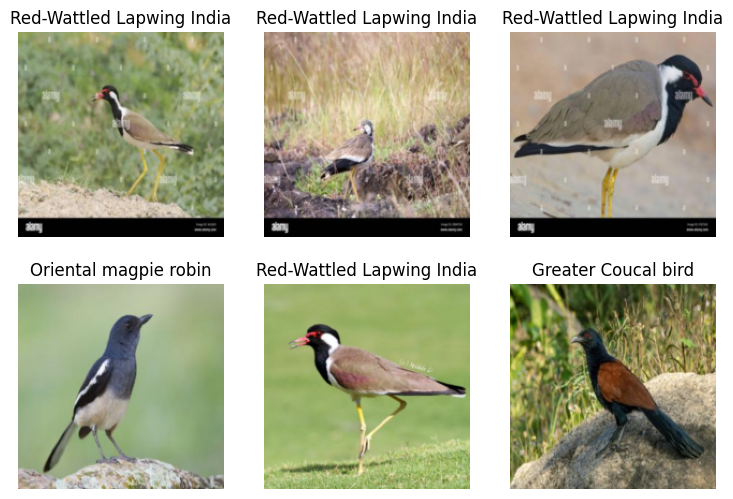

In [11]:
dls= DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(path, bs=32)

dls.show_batch(max_n=6)

In [12]:
learn=vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(3)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 48.5MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,1.652987,0.125699,0.040000,01:04


epoch,train_loss,valid_loss,error_rate,time
0,0.151385,0.040648,0.020000,01:36
1,0.098328,0.011524,0.000000,01:27
2,0.062165,0.012601,0.010000,01:25


In [95]:
urls=search_images('टिटहरी', max_images=1)

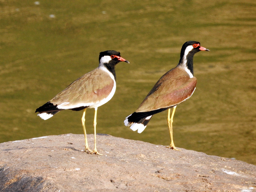

In [96]:
from fastdownload import download_url
dest='test.jpg'
download_url(urls[0],dest,show_progress=False)

from fastai.vision.all import *
im=Image.open(dest)
im.to_thumb(256,256)

In [97]:
pred, pred_idx, probs=learn.predict(PILImage.create("test.jpg"))
print(f"Predicted type: {pred}")
print(f"Confidence: {probs[pred_idx]:.4f}")

Predicted type: Red-Wattled Lapwing India
Confidence: 0.9996
